In [78]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import kruskal, spearmanr
import warnings
warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

In [79]:
file_path = "/content/seasonal_agriculture_performance_dataset.xlsx"
df = pd.read_excel(file_path)
print("Dataset loaded successfully.")
print("Shape:", df.shape)
df.head()

Dataset loaded successfully.
Shape: (4000, 28)


,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.40,24.30,69.10,5.80,7.14,32.80,75.80,61.30,91.00,Drip,242.70,4.33,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.49,55.30
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.40,25.70,78.40,5.10,5.20,32.00,82.10,35.40,121.80,Flood,271.40,6.86,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.40,49.90
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.60,23.90,56.40,10.30,5.82,8.10,118.50,51.50,117.90,Drip,162.60,6.08,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.98,33.70
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.20,29.70,65.20,6.30,5.98,23.70,138.60,55.60,115.50,Rainfed,182.20,6.39,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.16,50.60
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.60,34.10,55.20,6.50,6.90,29.30,124.10,69.00,121.40,Flood,244.90,7.61,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.83,32.30


In [80]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])
print("\nColumn names:")
for i, col in enumerate(df.columns, 1):
    print(i, "-", col)

Number of rows: 4000
Number of columns: 28

Column names:
1 - Farm_ID
2 - State
3 - District
4 - Crop
5 - Season
6 - Farm_Area_Hectares
7 - Rainfall_mm
8 - Avg_Temperature_C
9 - Humidity_pct
10 - Sunlight_Hours_Day
11 - Soil_pH
12 - Soil_Moisture_pct
13 - Nitrogen_kg_ha
14 - Phosphorus_kg_ha
15 - Potassium_kg_ha
16 - Irrigation_Method
17 - Fertilizer_kg_ha
18 - Pesticide_Litre_ha
19 - Seed_Quality_Score
20 - Yield_Tonnes_Ha
21 - Production_Tonnes
22 - Market_Price_INR_Tonne
23 - Total_Cost_INR
24 - Revenue_INR
25 - Profit_INR
26 - Water_Used_m3
27 - Water_Efficiency_t_per_1000m3
28 - Disease_Pest_Risk_pct


In [81]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Farm_ID                        4000 non-null   object 
 1   State                          4000 non-null   object 
 2   District                       4000 non-null   object 
 3   Crop                           4000 non-null   object 
 4   Season                         4000 non-null   object 
 5   Farm_Area_Hectares             4000 non-null   float64
 6   Rainfall_mm                    3952 non-null   float64
 7   Avg_Temperature_C              4000 non-null   float64
 8   Humidity_pct                   4000 non-null   float64
 9   Sunlight_Hours_Day             4000 non-null   float64
 10  Soil_pH                        4000 non-null   float64
 11  Soil_Moisture_pct              3960 non-null   float64
 12  Nitrogen_kg_ha                 4000 non-null   f

In [82]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Farm_ID,4000,4000,SF13984,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
State,4000,8,Andhra Pradesh,529,NaN,NaN,NaN,NaN,NaN,NaN,NaN
District,4000,10,Ludhiana,427,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Crop,4000,8,Rice,690,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Season,4000,3,Kharif,1779,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Farm_Area_Hectares,"4,000.00",NaN,NaN,NaN,7.89,4.22,0.50,4.26,7.89,11.65,15.00
Rainfall_mm,"3,952.00",NaN,NaN,NaN,601.15,288.93,80.00,370.20,582.00,834.95,"1,395.20"
Avg_Temperature_C,"4,000.00",NaN,NaN,NaN,26.82,3.82,16.20,23.90,26.90,29.60,39.70
Humidity_pct,"4,000.00",NaN,NaN,NaN,63.21,11.96,25.00,54.77,63.00,71.90,95.00
Sunlight_Hours_Day,"4,000.00",NaN,NaN,NaN,7.32,1.12,3.50,6.60,7.30,8.10,11.00


In [83]:
missing = df.isnull().sum()
missing_df = pd.DataFrame({
    "Missing Values": missing,
    "Missing Percentage": (missing / len(df)) * 100
})
missing_df = missing_df[missing_df["Missing Values"] > 0]
missing_df.sort_values("Missing Values", ascending=False)

,Missing Values,Missing Percentage
Rainfall_mm,48,1.20
Soil_Moisture_pct,40,1.00
Yield_Tonnes_Ha,32,0.80


In [84]:
duplicate_count = df.duplicated().sum()
print("Duplicate rows:", duplicate_count)

Duplicate rows: 0


In [85]:
categorical_columns = [
    "State",
    "District",
    "Crop",
    "Season",
    "Irrigation_Method"
]

for col in categorical_columns:
    print(f"\n{'='*50}")
    print(col)
    print(df[col].value_counts())


State
State
Andhra Pradesh    529
Telangana         516
Maharashtra       512
Madhya Pradesh    497
Karnataka         489
Gujarat           488
Tamil Nadu        485
Punjab            484
Name: count, dtype: int64

District
District
Ludhiana    427
Warangal    422
Nalgonda    415
Erode       403
Rajkot      401
Krishna     393
Indore      392
Guntur      390
Raichur     386
Nashik      371
Name: count, dtype: int64

Crop
Crop
Rice         690
Wheat        614
Maize        551
Cotton       508
Pulses       496
Groundnut    424
Chilli       412
Sugarcane    305
Name: count, dtype: int64

Season
Season
Kharif    1779
Rabi      1627
Zaid       594
Name: count, dtype: int64

Irrigation_Method
Irrigation_Method
Flood        1310
Rainfed      1041
Drip          915
Sprinkler     734
Name: count, dtype: int64


In [86]:
numeric_columns = df.select_dtypes(include=np.number).columns

for col in numeric_columns:
    df[col] = pd.to_numeric(df[col], errors="coerce")

print("Numeric conversion completed.")

Numeric conversion completed.


In [87]:
print("Missing values after numeric validation:")
print(df[numeric_columns].isnull().sum())

Missing values after numeric validation:
Farm_Area_Hectares                0
Rainfall_mm                      48
Avg_Temperature_C                 0
Humidity_pct                      0
Sunlight_Hours_Day                0
Soil_pH                           0
Soil_Moisture_pct                40
Nitrogen_kg_ha                    0
Phosphorus_kg_ha                  0
Potassium_kg_ha                   0
Fertilizer_kg_ha                  0
Pesticide_Litre_ha                0
Seed_Quality_Score                0
Yield_Tonnes_Ha                  32
Production_Tonnes                 0
Market_Price_INR_Tonne            0
Total_Cost_INR                    0
Revenue_INR                       0
Profit_INR                        0
Water_Used_m3                     0
Water_Efficiency_t_per_1000m3     0
Disease_Pest_Risk_pct             0
dtype: int64


In [88]:
checks = {
    "Negative Farm Area": (df["Farm_Area_Hectares"] < 0).sum(),
    "Negative Yield": (df["Yield_Tonnes_Ha"] < 0).sum(),
    "Negative Production": (df["Production_Tonnes"] < 0).sum(),
    "Negative Cost": (df["Total_Cost_INR"] < 0).sum(),
    "Negative Water Used": (df["Water_Used_m3"] < 0).sum(),
    "Invalid Humidity": ((df["Humidity_pct"] < 0) | (df["Humidity_pct"] > 100)).sum(),
    "Invalid Disease Risk": ((df["Disease_Pest_Risk_pct"] < 0) |
                             (df["Disease_Pest_Risk_pct"] > 100)).sum()
}

pd.Series(checks, name="Count")

,Count
Negative Farm Area,0
Negative Yield,0
Negative Production,0
Negative Cost,0
Negative Water Used,0
Invalid Humidity,0
Invalid Disease Risk,0


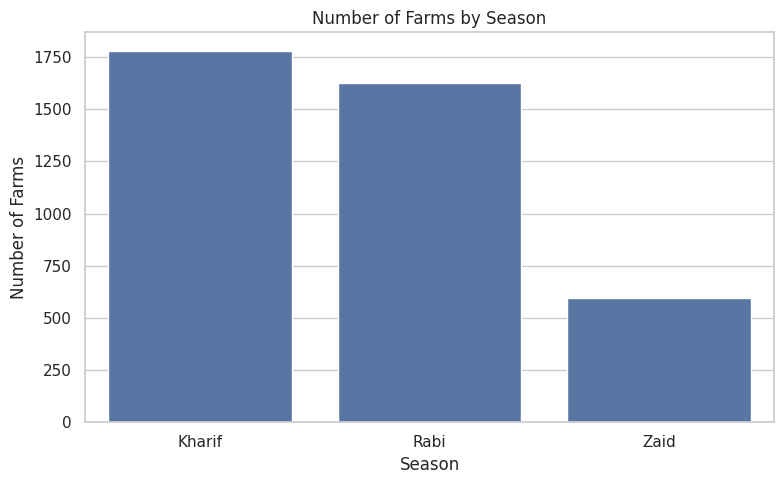

In [89]:
season_counts = df["Season"].value_counts()

plt.figure(figsize=(8, 5))
sns.barplot(
    x=season_counts.index,
    y=season_counts.values
)

plt.title("Number of Farms by Season")
plt.xlabel("Season")
plt.ylabel("Number of Farms")
plt.tight_layout()
plt.show()

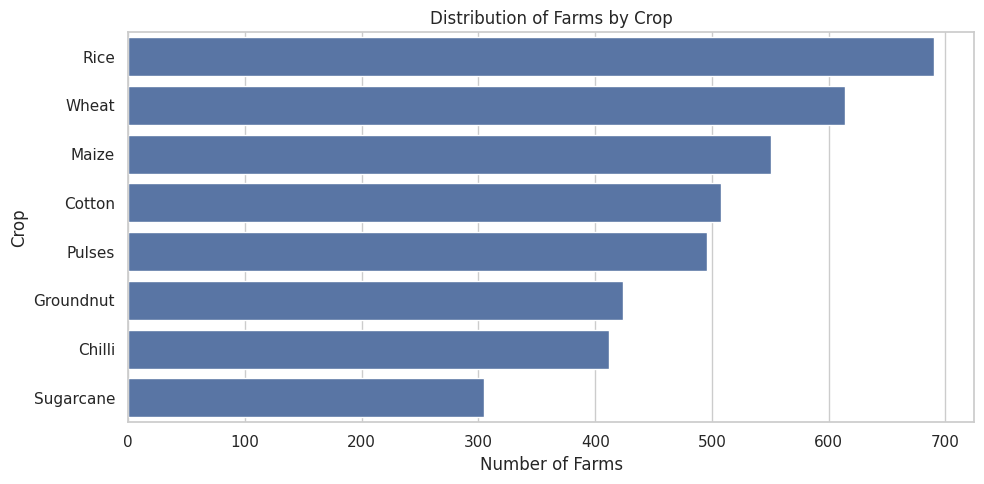

In [90]:
plt.figure(figsize=(10, 5))

order = df["Crop"].value_counts().index

sns.countplot(
    data=df,
    y="Crop",
    order=order
)

plt.title("Distribution of Farms by Crop")
plt.xlabel("Number of Farms")
plt.ylabel("Crop")
plt.tight_layout()
plt.show()

In [91]:
season_yield = (
    df.groupby("Season")["Yield_Tonnes_Ha"]
    .mean()
    .sort_values(ascending=False)
)

print(season_yield)

Season
Kharif   5.64
Rabi     5.08
Zaid     4.67
Name: Yield_Tonnes_Ha, dtype: float64


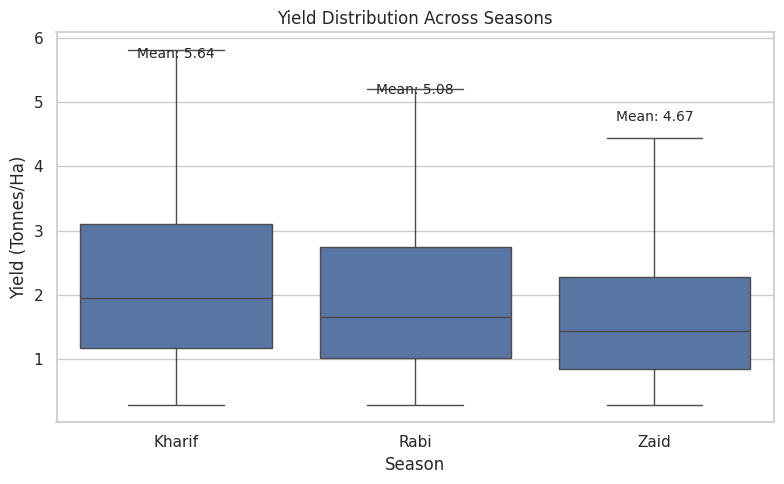

In [92]:
plt.figure(figsize=(8, 5))

ax = sns.boxplot(
    data=df,
    x="Season",
    y="Yield_Tonnes_Ha",
    showfliers=False
)

means = df.groupby("Season")["Yield_Tonnes_Ha"].mean()

for i, season in enumerate(ax.get_xticklabels()):
    season_name = season.get_text()
    mean_value = means[season_name]

    ax.text(
        i,
        mean_value,
        f"Mean: {mean_value:.2f}",
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.title("Yield Distribution Across Seasons")
plt.xlabel("Season")
plt.ylabel("Yield (Tonnes/Ha)")
plt.tight_layout()
plt.show()

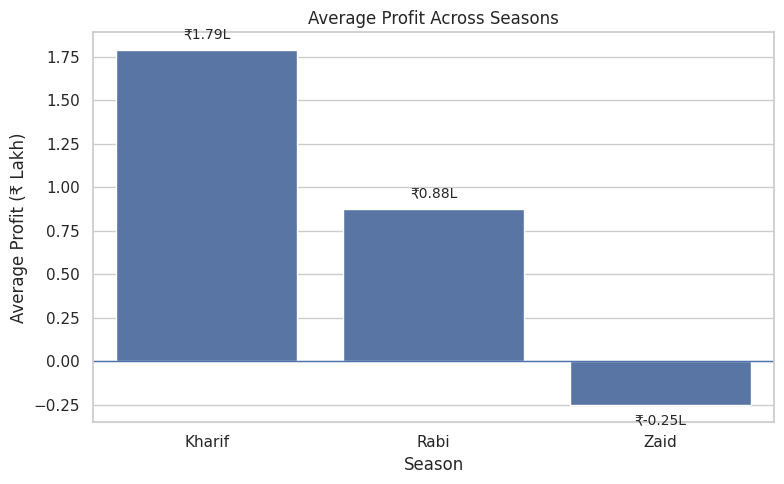

In [93]:
season_order = ["Kharif", "Rabi", "Zaid"]

season_profit = (
    df.groupby("Season")["Profit_INR"]
    .mean()
    .reindex(season_order)
)

plt.figure(figsize=(8, 5))

ax = sns.barplot(
    x=season_profit.index,
    y=season_profit.values / 100000
)

for bar, value in zip(ax.patches, season_profit.values / 100000):
    ax.annotate(
        f"₹{value:.2f}L",
        (bar.get_x() + bar.get_width() / 2, value),
        ha="center",
        va="bottom" if value >= 0 else "top",
        xytext=(0, 6 if value >= 0 else -6),
        textcoords="offset points",
        fontsize=10
    )

plt.axhline(0, linewidth=1)

plt.title("Average Profit Across Seasons")
plt.xlabel("Season")
plt.ylabel("Average Profit (₹ Lakh)")

plt.tight_layout()
plt.show()

In [94]:
season_summary = df.groupby("Season").agg({
    "Yield_Tonnes_Ha": "mean",
    "Production_Tonnes": "mean",
    "Revenue_INR": "mean",
    "Total_Cost_INR": "mean",
    "Profit_INR": "mean",
    "Water_Used_m3": "mean",
    "Water_Efficiency_t_per_1000m3": "mean",
    "Disease_Pest_Risk_pct": "mean"
}).round(2)

season_summary

,Yield_Tonnes_Ha,Production_Tonnes,Revenue_INR,Total_Cost_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
Season,,,,,,,,
Kharif,5.64,46.31,"710,719.06","531,804.41","178,914.65","6,102.20",5.89,54.47
Rabi,5.08,41.49,"601,526.05","513,836.58","87,689.47","5,846.99",5.19,40.48
Zaid,4.67,38.89,"519,171.90","543,976.73","-24,804.82","6,419.89",4.41,38.22


In [95]:
crop_season_yield = pd.pivot_table(
    df,
    values="Yield_Tonnes_Ha",
    index="Crop",
    columns="Season",
    aggfunc="mean"
)

crop_season_yield

Season,Kharif,Rabi,Zaid
Crop,,,
Chilli,1.73,1.46,1.18
Cotton,1.37,1.19,0.95
Groundnut,1.48,1.22,1.04
Maize,2.97,2.61,2.30
Pulses,1.04,0.87,0.65
Rice,2.71,2.33,1.90
Sugarcane,53.46,43.94,38.42
Wheat,2.26,2.06,1.75


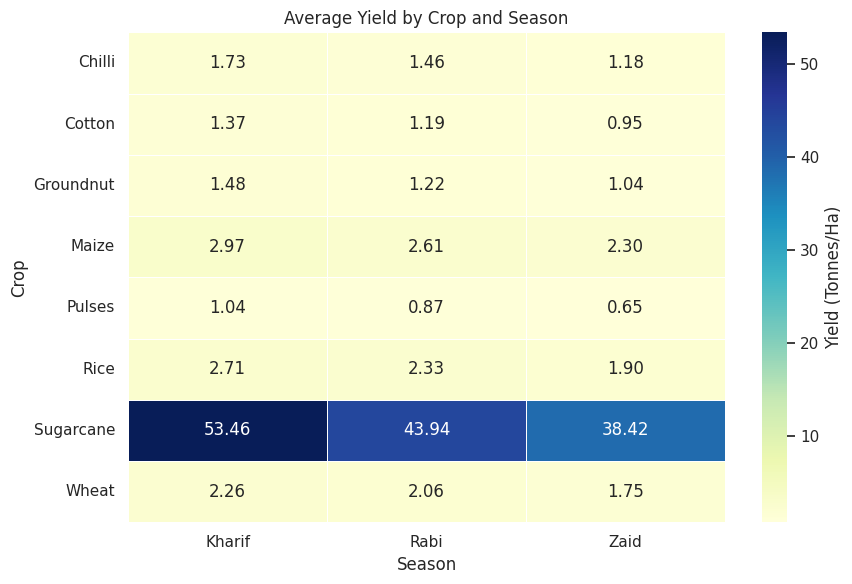

In [96]:
season_order = ["Kharif", "Rabi", "Zaid"]

crop_season_yield = pd.pivot_table(
    df,
    values="Yield_Tonnes_Ha",
    index="Crop",
    columns="Season",
    aggfunc="mean"
).reindex(columns=season_order)

plt.figure(figsize=(9, 6))

sns.heatmap(
    crop_season_yield,
    annot=True,
    fmt=".2f",
    cmap="YlGnBu",
    linewidths=0.5,
    cbar_kws={"label": "Yield (Tonnes/Ha)"}
)

plt.title("Average Yield by Crop and Season")
plt.xlabel("Season")
plt.ylabel("Crop")

plt.tight_layout()
plt.show()

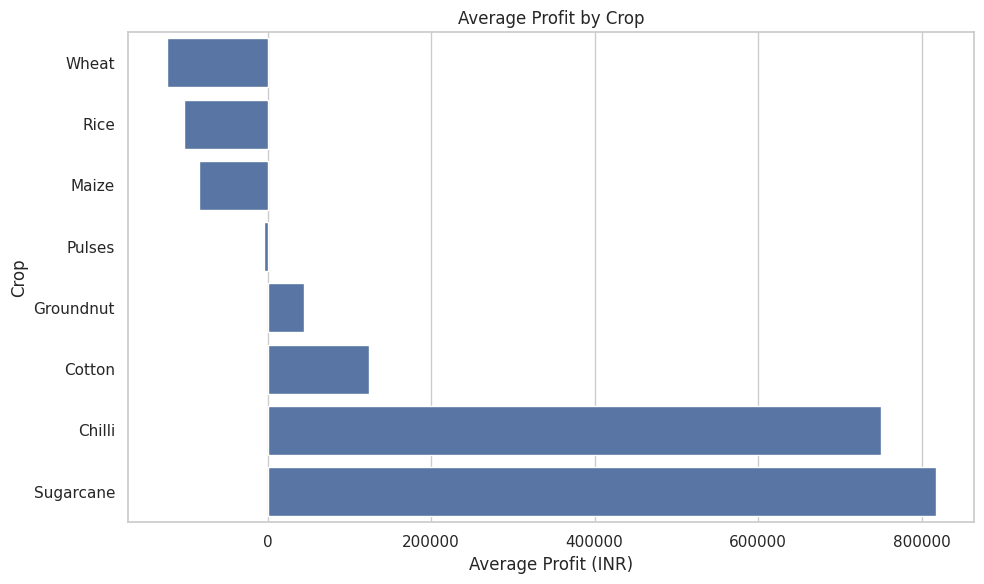

In [116]:
crop_profit = (
    df.groupby("Crop")["Profit_INR"]
    .mean()
    .sort_values(ascending=True)
)

plt.figure(figsize=(10, 6))

sns.barplot(
    x=crop_profit.values,
    y=crop_profit.index
)

plt.title("Average Profit by Crop")
plt.xlabel("Average Profit (INR)")
plt.ylabel("Crop")
plt.tight_layout()
plt.show()

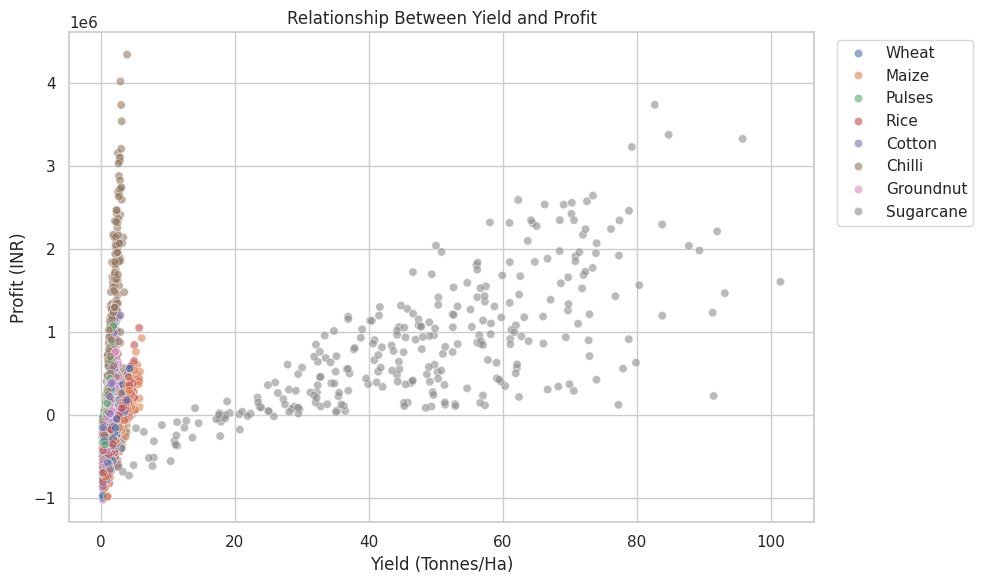

In [98]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="Yield_Tonnes_Ha",
    y="Profit_INR",
    hue="Crop",
    alpha=0.6
)

plt.title("Relationship Between Yield and Profit")
plt.xlabel("Yield (Tonnes/Ha)")
plt.ylabel("Profit (INR)")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()
plt.show()

In [99]:
irrigation_summary = df.groupby("Irrigation_Method").agg({
    "Yield_Tonnes_Ha": "mean",
    "Profit_INR": "mean",
    "Water_Used_m3": "mean",
    "Water_Efficiency_t_per_1000m3": "mean"
}).round(2)

irrigation_summary

,Yield_Tonnes_Ha,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3
Irrigation_Method,,,,
Drip,6.62,"219,626.00","5,918.75",6.27
Flood,4.90,"73,354.02","8,026.47",3.44
Rainfed,4.61,"79,050.37","3,549.55",7.56
Sprinkler,5.19,"91,121.08","6,208.26",4.67


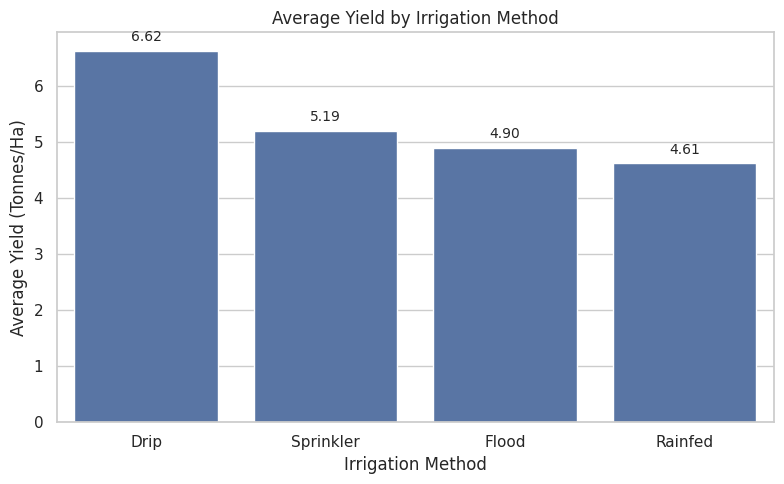

In [100]:
irrigation_yield = (
    df.groupby("Irrigation_Method")["Yield_Tonnes_Ha"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(8, 5))

ax = sns.barplot(
    x=irrigation_yield.index,
    y=irrigation_yield.values
)

for bar, value in zip(ax.patches, irrigation_yield.values):
    ax.annotate(
        f"{value:.2f}",
        (bar.get_x() + bar.get_width() / 2, value),
        ha="center",
        va="bottom",
        xytext=(0, 5),
        textcoords="offset points",
        fontsize=10
    )

plt.title("Average Yield by Irrigation Method")
plt.xlabel("Irrigation Method")
plt.ylabel("Average Yield (Tonnes/Ha)")

plt.tight_layout()
plt.show()

In [101]:
profitability = (
    df.assign(Profitable=df["Profit_INR"] > 0)
    .groupby("Irrigation_Method")["Profitable"]
    .mean() * 100
)

profitability = profitability.sort_values(ascending=False)

print(profitability.round(2))

Irrigation_Method
Drip        59.78
Sprinkler   51.91
Flood       47.18
Rainfed     46.88
Name: Profitable, dtype: float64


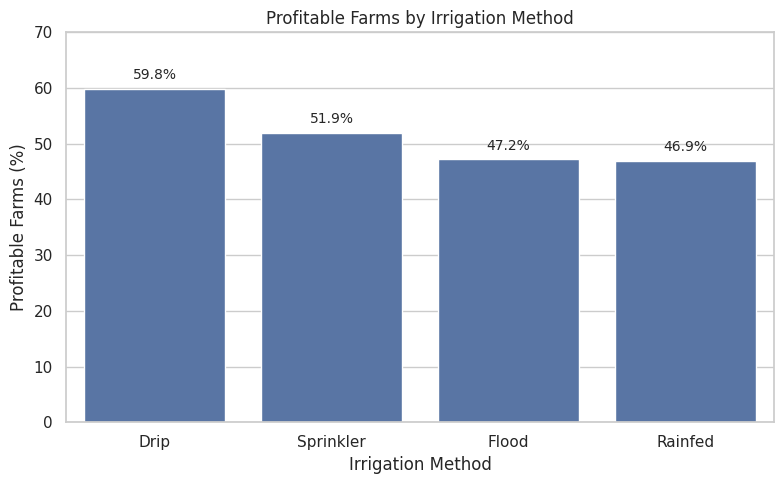

In [102]:
# Percentage of Profitable Farms by Irrigation Method

profitability = (
    df.assign(Profitable=df["Profit_INR"] > 0)
      .groupby("Irrigation_Method")["Profitable"]
      .mean()
      .mul(100)
      .sort_values(ascending=False)
)

plt.figure(figsize=(8, 5))

ax = sns.barplot(
    x=profitability.index,
    y=profitability.values
)

for bar, value in zip(ax.patches, profitability.values):
    ax.annotate(
        f"{value:.1f}%",
        (bar.get_x() + bar.get_width() / 2, value),
        ha="center",
        va="bottom",
        xytext=(0, 5),
        textcoords="offset points",
        fontsize=10
    )

plt.title("Profitable Farms by Irrigation Method")
plt.xlabel("Irrigation Method")
plt.ylabel("Profitable Farms (%)")
plt.ylim(0, 70)

plt.tight_layout()
plt.show()

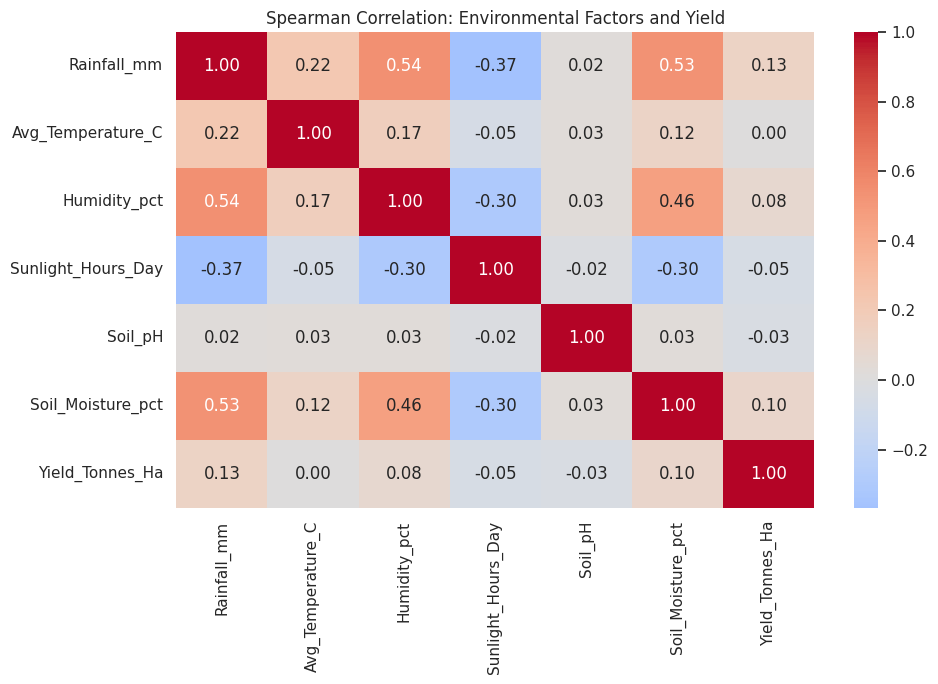

In [103]:
environmental_columns = [
    "Rainfall_mm",
    "Avg_Temperature_C",
    "Humidity_pct",
    "Sunlight_Hours_Day",
    "Soil_pH",
    "Soil_Moisture_pct"
]

corr_data = df[
    environmental_columns + ["Yield_Tonnes_Ha"]
].corr(method="spearman")

plt.figure(figsize=(10, 7))

sns.heatmap(
    corr_data,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Spearman Correlation: Environmental Factors and Yield")
plt.tight_layout()
plt.show()

In [104]:
environmental_correlations = (
    df[environmental_columns + ["Yield_Tonnes_Ha"]]
    .corr(method="spearman")["Yield_Tonnes_Ha"]
    .drop("Yield_Tonnes_Ha")
    .sort_values()
)

environmental_correlations

,Yield_Tonnes_Ha
Sunlight_Hours_Day,-0.05
Soil_pH,-0.03
Avg_Temperature_C,0.00
Humidity_pct,0.08
Soil_Moisture_pct,0.10
Rainfall_mm,0.13


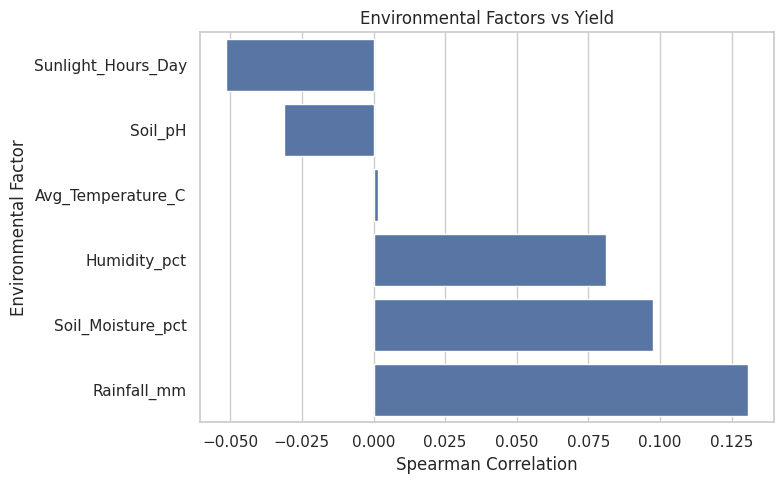

In [105]:
plt.figure(figsize=(8, 5))

sns.barplot(
    x=environmental_correlations.values,
    y=environmental_correlations.index
)

plt.title("Environmental Factors vs Yield")
plt.xlabel("Spearman Correlation")
plt.ylabel("Environmental Factor")

plt.tight_layout()
plt.show()

In [106]:
risk_by_season = (
    df.groupby("Season")["Disease_Pest_Risk_pct"]
    .mean()
    .sort_values(ascending=False)
)

print(risk_by_season.round(2))

Season
Kharif   54.47
Rabi     40.48
Zaid     38.22
Name: Disease_Pest_Risk_pct, dtype: float64


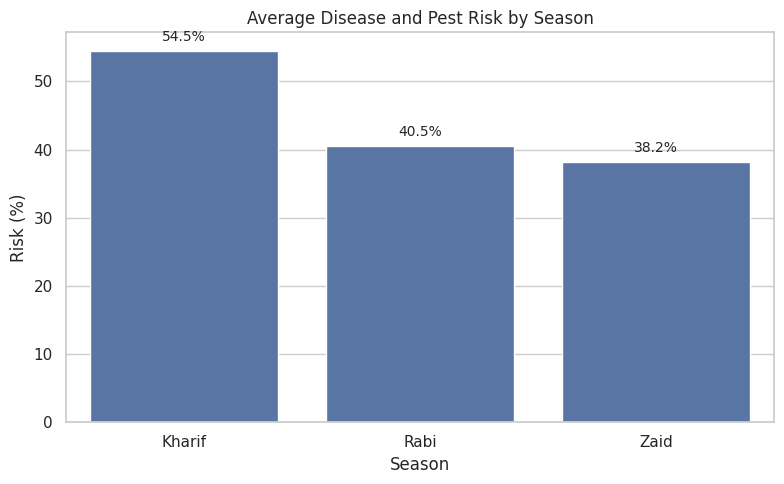

In [107]:
season_risk = (
    df.groupby("Season")["Disease_Pest_Risk_pct"]
    .mean()
    .reindex(["Kharif", "Rabi", "Zaid"])
)

plt.figure(figsize=(8, 5))

ax = sns.barplot(
    x=season_risk.index,
    y=season_risk.values
)

for bar, value in zip(ax.patches, season_risk.values):
    ax.annotate(
        f"{value:.1f}%",
        (bar.get_x() + bar.get_width() / 2, value),
        ha="center",
        va="bottom",
        xytext=(0, 5),
        textcoords="offset points",
        fontsize=10
    )

plt.title("Average Disease and Pest Risk by Season")
plt.xlabel("Season")
plt.ylabel("Risk (%)")

plt.tight_layout()
plt.show()

In [108]:
profit_season = (
    df.groupby("Season")["Profit_INR"]
    .mean()
    .sort_values(ascending=False)
)

print(profit_season.round(2))

Season
Kharif   178,914.65
Rabi      87,689.47
Zaid     -24,804.82
Name: Profit_INR, dtype: float64


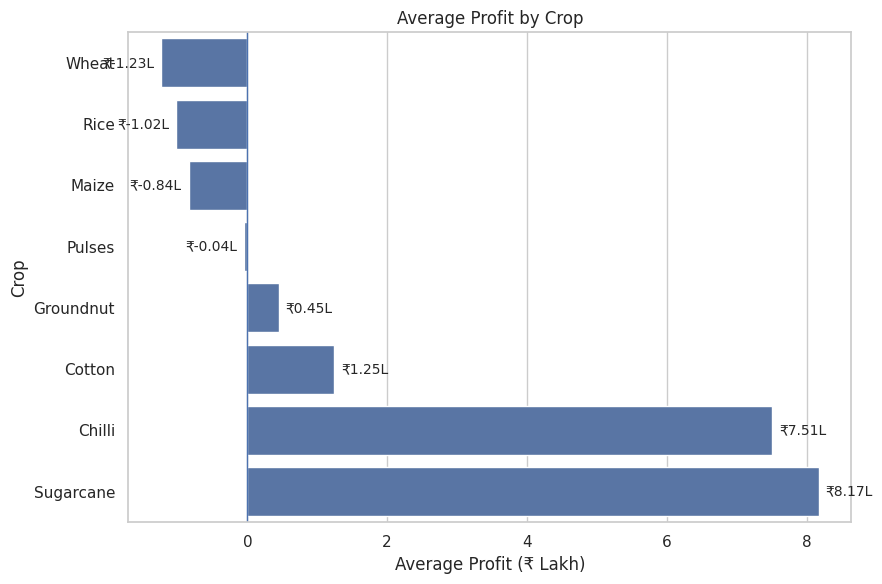

In [109]:
crop_profit = (
    df.groupby("Crop")["Profit_INR"]
    .mean()
    .sort_values(ascending=True)
)

plt.figure(figsize=(9, 6))

ax = sns.barplot(
    x=crop_profit.values / 100000,
    y=crop_profit.index
)

for bar, value in zip(ax.patches, crop_profit.values / 100000):
    ax.annotate(
        f"₹{value:.2f}L",
        (value, bar.get_y() + bar.get_height() / 2),
        ha="left" if value >= 0 else "right",
        va="center",
        xytext=(5 if value >= 0 else -5, 0),
        textcoords="offset points",
        fontsize=10
    )

plt.axvline(0, linewidth=1)

plt.title("Average Profit by Crop")
plt.xlabel("Average Profit (₹ Lakh)")
plt.ylabel("Crop")

plt.tight_layout()
plt.show()

In [110]:
season_groups = [
    group["Yield_Tonnes_Ha"].dropna()
    for _, group in df.groupby("Season")
]

kruskal_result = kruskal(*season_groups)

print("Kruskal-Wallis Test")
print("--------------------")
print("H-statistic:", round(kruskal_result.statistic, 2))
print("p-value:", kruskal_result.pvalue)

Kruskal-Wallis Test
--------------------
H-statistic: 68.6
p-value: 1.2669705784969668e-15


In [111]:
yield_with_sugarcane = (
    df.groupby("Season")["Yield_Tonnes_Ha"]
    .mean()
)

yield_without_sugarcane = (
    df[df["Crop"] != "Sugarcane"]
    .groupby("Season")["Yield_Tonnes_Ha"]
    .mean()
)

comparison = pd.DataFrame({
    "All Crops": yield_with_sugarcane,
    "Excluding Sugarcane": yield_without_sugarcane
})

comparison.round(2)

,All Crops,Excluding Sugarcane
Season,,
Kharif,5.64,2.02
Rabi,5.08,1.75
Zaid,4.67,1.47


In [112]:
state_district = (
    df.groupby("State")["District"]
    .nunique()
    .sort_values(ascending=False)
)

state_district

,District
State,
Andhra Pradesh,10
Gujarat,10
Karnataka,10
Madhya Pradesh,10
Maharashtra,10
Punjab,10
Tamil Nadu,10
Telangana,10


In [113]:
state_district_table = pd.crosstab(
    df["State"],
    df["District"]
)

state_district_table

District,Erode,Guntur,Indore,Krishna,Ludhiana,Nalgonda,Nashik,Raichur,Rajkot,Warangal
State,,,,,,,,,,
Andhra Pradesh,45,49,47,54,56,57,44,63,65,49
Gujarat,61,58,34,35,54,54,39,52,48,53
Karnataka,39,44,42,54,56,52,52,44,58,48
Madhya Pradesh,39,51,48,54,57,50,43,47,46,62
Maharashtra,47,53,51,59,46,57,54,46,52,47
Punjab,53,46,45,56,48,49,50,43,37,57
Tamil Nadu,51,52,54,39,61,34,41,56,48,49
Telangana,68,37,71,42,49,62,48,35,47,57


In [114]:
df.groupby("Season")["Yield_Tonnes_Ha"].mean()

,Yield_Tonnes_Ha
Season,
Kharif,5.64
Rabi,5.08
Zaid,4.67
